스케일이 다르면 거리가 왜곡된다

길이 범위:  8 ~ 44  (cm)   → 최대 차이 36
무게 범위:  6 ~ 1100 (g)   → 최대 차이 1094



A = [20.0, 500.0]   # 길이 20cm, 무게 500g
B = [44.0, 501.0]   # 길이 44cm, 무게 501g
new = [22.0, 499.0] # 새 샘플
d_A = np.sqrt((22-20)**2 + (499-500)**2)  # ≈ 2.2
d_B = np.sqrt((22-44)**2 + (499-501)**2)  # ≈ 22.1


'''new는 길이로 보면 A와 가깝지만
무게 차이 때문에 거리는 B가 훨씬 더 크다 
✓
→ 사실 new는 A와 비슷한 생선인데 올바른 판단
일까?'''


정규화 vs 표준화

정규화 (x-뮤) / 시그마(=표준편차)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

In [5]:
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])

In [6]:
# 훈련 데이터 테스트 데이터 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [7]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [8]:
model = KNeighborsRegressor()
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
# 데이터 전처리 -> 모델이 원하는 입력 형태로 만들어주기 위해서
train_input = test_input.reshape(-1,1) # 형태(구조)를 변경해준다. 1차원 -> 2차원 행렬로
test_input = test_input.reshape(-1,1)

In [17]:
#사이킷 런 모델은 X(Feature) 데이터로 2차원 배열을 입력받기 원함.
model = KNeighborsRegressor()
model.fit(train_input,test_input)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
#평가 : R^2 결정계수
model.score(test_input,test_target)

-0.862565019307439

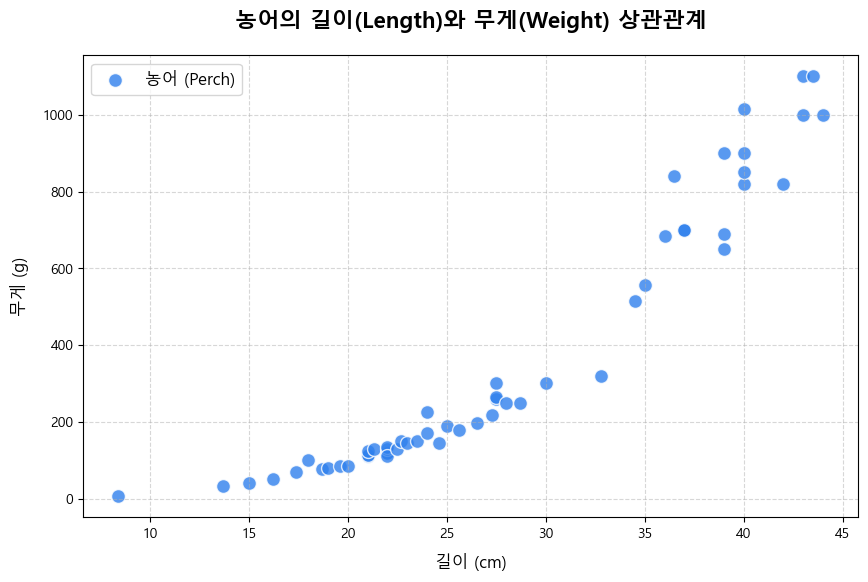

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 및 마이너스 기호 깨짐 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 농어(Perch) 데이터 정의
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 
     27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 
     36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 
     42.0, 43.0, 43.0, 43.5, 44.0]
)
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0, 
     150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 
     300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0, 
     685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0, 
     820.0, 1100.0, 1000.0, 1100.0, 1000.0]
)

# 3. 분포 시각화 (산점도 그리기)
plt.figure(figsize=(10, 6))
plt.scatter(
    perch_length, 
    perch_weight, 
    color='#2F80ED',   # 깔끔한 블루 톤
    alpha=0.8,         # 겹친 데이터 식별을 위한 투명도
    edgecolors='white',# 마커 테두리
    s=100,             # 마커 크기
    label='농어 (Perch)'
)

# 4. 차트 꾸미기 (타이틀 및 라벨 구성)
plt.title('농어의 길이(Length)와 무게(Weight) 상관관계', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('길이 (cm)', fontsize=12, labelpad=10)
plt.ylabel('무게 (g)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5) # 격자망 설정
plt.legend(fontsize=12, loc='upper left')

plt.show()


In [20]:
from sklearn.metrics import mean_absolute_error # MAE
test_prediction = model.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)   # 19.16

302.04857142857145


In [ ]:
#k 값의 변화에 따라서, 그래프를 그려보자
# k값이 1, 5, 10일때


model = KNeighborsRegressor()
x = np.arange(5,45).reshape(-1,1)
for n in [1,5,10] :
    model.n_neighbors =n 
    model.fit(train_input, train_target)
    prediction = model.predict(x)
    plt.scatter(train_input,train_target)
    plt.plot(x, prediction)
    plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [14, 42]

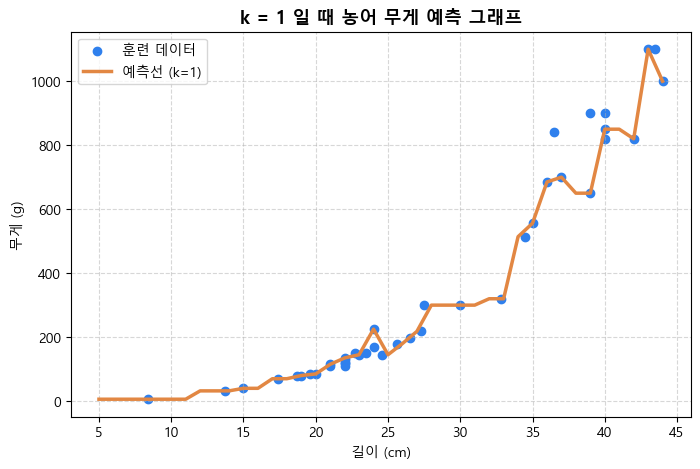

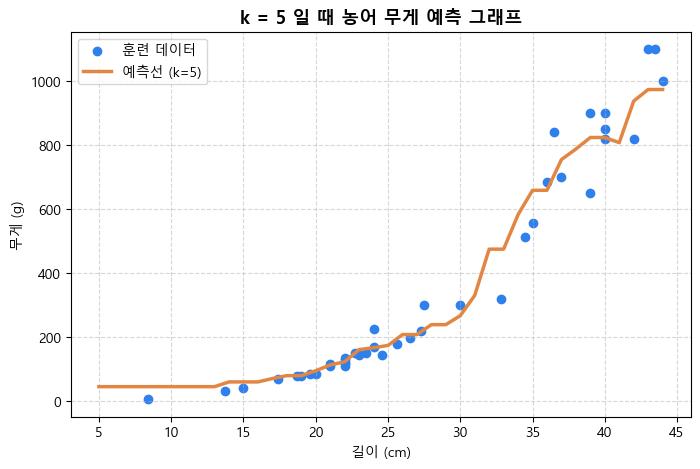

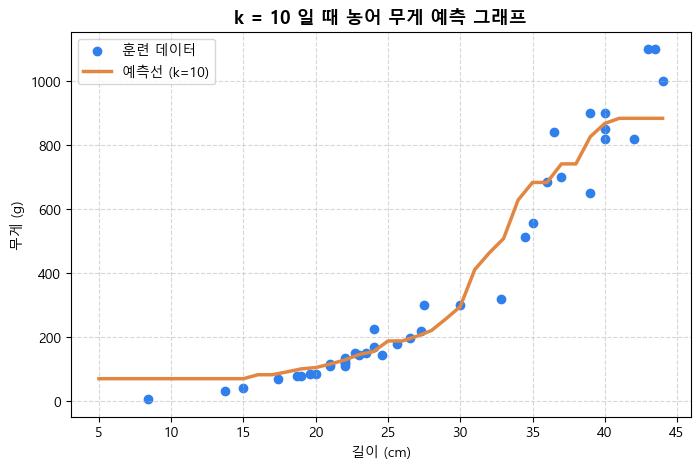

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# 1. 농어 데이터 정의
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 
     27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 
     36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 
     42.0, 43.0, 43.0, 43.5, 44.0]
)
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0, 
     150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 
     300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0, 
     685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0, 
     820.0, 1100.0, 1000.0, 1100.0, 1000.0]
)

# 2. 훈련/테스트 세트 분할 (★변수 할당 순서 주의!)
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

# 3. 1차원 데이터 -> 2차원 데이터 변환
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# 4. 모델 생성 및 예측용 축(x) 설정
model = KNeighborsRegressor()
x = np.arange(5, 45).reshape(-1, 1)

# 5. k값(1, 5, 10)의 변화에 따라 회귀 그래프 그리기
for n in [1, 5, 10]:
    # k값 설정
    model.n_neighbors = n 
    # 모델 훈련
    model.fit(train_input, train_target)
    # 예측값 생성
    prediction = model.predict(x)
    
    # 그래프 그리기
    plt.figure(figsize=(8, 5))
    plt.scatter(train_input, train_target, color='#2F80ED', label='훈련 데이터')
    plt.plot(x, prediction, color='#E28743', linewidth=2.5, label=f'예측선 (k={n})')
    plt.title(f'k = {n} 일 때 농어 무게 예측 그래프', fontsize=13, fontweight='bold')
    plt.xlabel('길이 (cm)')
    plt.ylabel('무게 (g)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


3. 선형 회귀 + MSE + 경사 하강법


In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(train_input, train_target)

print(model.predict([[500]])) # knn이 못하는 외삽(extrapolation) 예측을 함
model.score(test_input,test_target) #결정계수 R^2

[16973.26421467]


0.9027635575388178

In [ ]:
print(model.coef_) #기울기
print(model.intercept_) #b 절편

[35.16641176]
-609.9416628584297


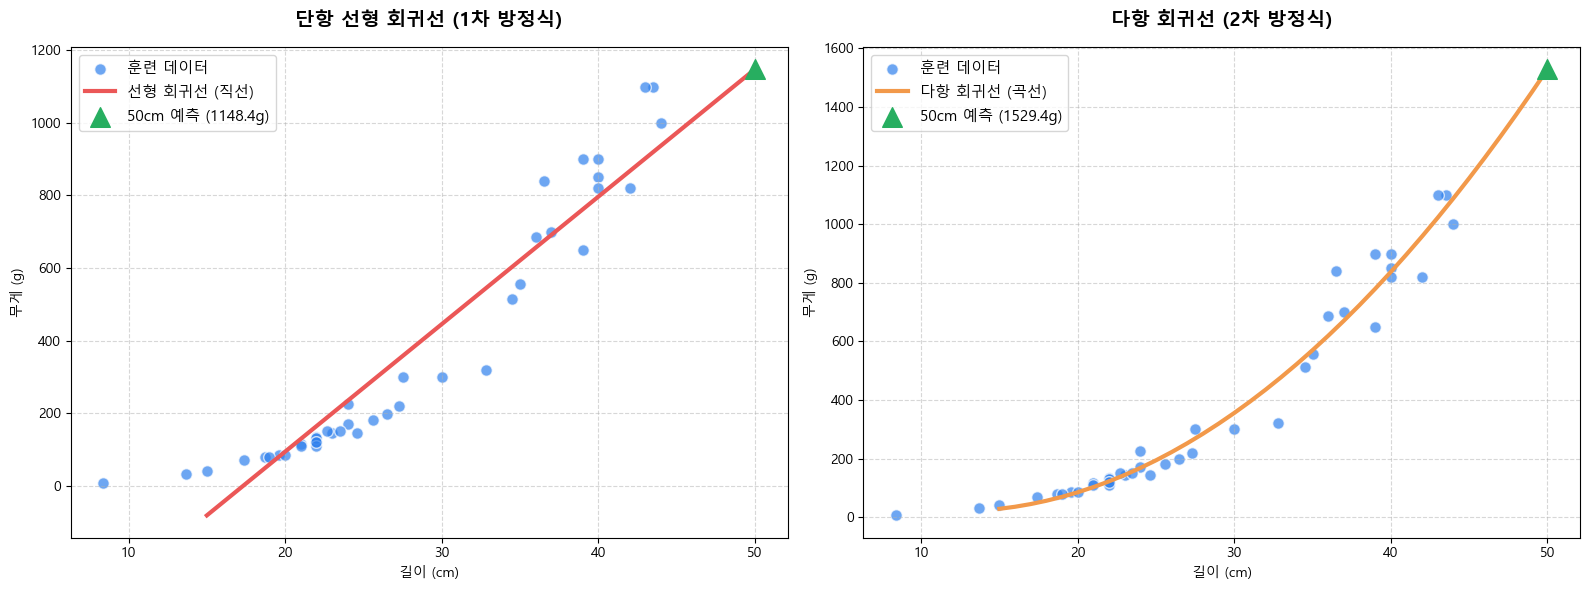

In [32]:
#회귀선이 담긴 그래프
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 농어 데이터 정의
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 
     27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 
     36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 
     42.0, 43.0, 43.0, 43.5, 44.0]
)
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0, 
     150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 
     300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0, 
     685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0, 900.0, 1015.0, 
     820.0, 1100.0, 1000.0, 1100.0, 1000.0]
)

# 3. 데이터 분할 및 2차원 변환
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

# ----------------------------------------------------
# [모델 1] 단항 선형 회귀 (Simple Linear Regression) - 직선
# ----------------------------------------------------
lr_linear = LinearRegression()
lr_linear.fit(train_input, train_target)

# 50cm 농어의 예측 무게
pred_50_linear = lr_linear.predict([[50]])[0] 


# ----------------------------------------------------
# [모델 2] 다항 선형 회귀 (Polynomial Regression) - 곡선
# ----------------------------------------------------
# 2차 방정식 학습을 위해 길이를 제곱한 피처 추가 (길이^2, 길이)
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

lr_poly = LinearRegression()
lr_poly.fit(train_poly, train_target)

# 50cm 농어의 예측 무게 (50^2, 50 대입)
pred_50_poly = lr_poly.predict([[50**2, 50]])[0]


# ----------------------------------------------------
# 📊 시각화 통합 차트 작성
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: 단항 선형 회귀선 (직선) ---
axes[0].scatter(train_input, train_target, color='#2F80ED', alpha=0.7, edgecolors='w', s=70, label='훈련 데이터')
# 회귀 직선 그리기 (y = ax + b)
axes[0].plot([15, 50], [15*lr_linear.coef_[0] + lr_linear.intercept_, 50*lr_linear.coef_[0] + lr_linear.intercept_], 
             color='#EB5757', linewidth=3, label='선형 회귀선 (직선)')
# 50cm 농어 예측 포인트 표시
axes[0].scatter(50, pred_50_linear, color='#27AE60', marker='^', s=200, zorder=5, label=f'50cm 예측 ({pred_50_linear:.1f}g)')

axes[0].set_title('단항 선형 회귀선 (1차 방정식)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('길이 (cm)')
axes[0].set_ylabel('무게 (g)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=11)

# --- Graph 2: 다항 회귀선 (곡선) ---
axes[1].scatter(train_input, train_target, color='#2F80ED', alpha=0.7, edgecolors='w', s=70, label='훈련 데이터')
# 매끄러운 곡선을 그리기 위해 구간 포인트 생성 (15 ~ 50)
point = np.arange(15, 51)
# 2차 방정식 예측 곡선 그리기 (y = a*x^2 + b*x + c)
poly_curve = lr_poly.coef_[0]*(point**2) + lr_poly.coef_[1]*point + lr_poly.intercept_
axes[1].plot(point, poly_curve, color='#F2994A', linewidth=3, label='다항 회귀선 (곡선)')
# 50cm 농어 예측 포인트 표시
axes[1].scatter(50, pred_50_poly, color='#27AE60', marker='^', s=200, zorder=5, label=f'50cm 예측 ({pred_50_poly:.1f}g)')

axes[1].set_title('다항 회귀선 (2차 방정식)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('길이 (cm)')
axes[1].set_ylabel('무게 (g)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
# MSE : 평균 제곱 오차
from sklearn.metrics import mean_squared_error
mean_squared_error(test_target, test_prediction)

217865.3244857143

In [35]:
model = LinearRegression()
model.fit(train_poly, train_target)
model.predict([ [50**2, 50 ]])

array([1529.35643599])

In [37]:
# parameter 를 구해본다.
print(model.coef_)

[  1.0533811  -25.58358998]


### 2차 방정식
$1x^2 - 21x + 116 $

In [ ]:
#시각화
